In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

import logomaker

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [76]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')

In [48]:
np.unique(SAV_ABE1['gRNA_id'])

array(['gRNA_CDK19_targ_6273', 'gRNA_CDK19_targ_6274',
       'gRNA_CDK19_targ_6275', ..., 'gRNA_CDK9_targ_1737',
       'gRNA_CDK9_targ_1738', 'gRNA_CDK9_targ_1739'], dtype=object)

In [59]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]



def logo_df_maker(merge, gRNA_id, context_size, min_perc):

    gene = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]

    cdks = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

    cdk_prot = cdks.loc[cdks['Gene']==gene, 'Protein'].values[0]

    d4 = merge[(merge['HGVSp']!='WT') & (merge['%Reads']>=min_perc) & (merge['gRNA_id']==gRNA_id)]
    
    codons = []
    refs = []
    alts = []
    for i, val in d4.iterrows():
        h = val['HGVSp']
        c = val['%Reads']

        codon = extract_numbers(h)
        ref = h[0]
        alt = h[-1]
        codons.append(codon)
        refs.append(ref)
        alts.append(alt)

    d4['codon'] = codons
    d4['ref'] = refs
    d4['alt'] = alts

    min_cod = min(d4['codon'])
    max_cod = max(d4['codon'])

    assert cdk_prot[min_cod-1] == d4.loc[d4['codon']==min_cod, 'ref'].values[0]
    assert cdk_prot[max_cod-1] == d4.loc[d4['codon']==max_cod, 'ref'].values[0]

    start_cod = max(min_cod-context_size, 0)
    end_cod = min(max_cod +context_size, len(cdk_prot))

    codon_options = np.unique([i for i in cdk_prot[start_cod-1: end_cod]] + refs + alts)

    sequence = cdk_prot[start_cod-1: end_cod]
    seq_length = len(sequence)

    zero_array = [list(range(start_cod, end_cod+1))] + [np.zeros(seq_length) for i in range(len(codon_options))]

    logo_df = pd.DataFrame(dict(zip(['codon'] + list(codon_options), zero_array)))

    for i, val in d4.iterrows():
        cod = val['codon']
        alt = val['alt']
        perc = val['%Reads']

        logo_df.loc[logo_df['codon']==cod, alt]+=perc

    for i, val in enumerate(list(range(start_cod, end_cod+1))):
        cod = val
        aa = sequence[i]

        remaining_prob = 100 - np.sum(logo_df[logo_df['codon']==cod][codon_options].values)

        logo_df.loc[logo_df['codon']==cod, aa]+=remaining_prob

    logo_df = logo_df.set_index('codon')

    return logo_df, min_cod, max_cod, d4, sequence

In [58]:
gene = merge.loc[merge['gRNA_id']=='gRNA_id', 'Gene']
gene

Series([], Name: Gene, dtype: object)

In [112]:
def logo_plotter(gRNA_id, logo_df, ABE1, d4, min_perc):
    
    fig, ax = plt.subplots(figsize=(8,2))
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=12)
    ss_logo.ax.set_yticks([0,25, 50, 75,100])
    ss_logo.ax.set_yticklabels([0,25, 50, 75,100], fontsize=12);
    ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['left', 'right', 'top'], visible=False)

    subset = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]

    s2 = ''
    for i, val in subset[:5].iterrows():
        pp = val['%Reads']
        s2 += f"{val['HGVSp']}, {np.round(pp,1)}%, "


    ss_logo.ax.set_title(f'{s2}', fontsize=14)

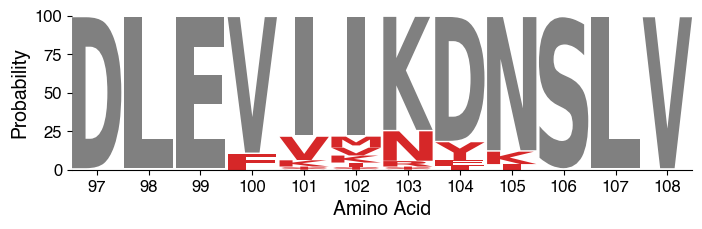

In [285]:
merge = SAV_CBE1
gRNA_id = 'gRNA_CDK7_targ_74'
context_size=3
min_perc = 2

logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

logo_plotter(gRNA_id, logo_df, CBE1, d4, min_perc=2)

# ALSO MAKE A DNA VERSION

# Combined plots

In [257]:
data = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')

condition = 'BSJ-4-116'
FDR_cutoff = 0.1

all_conditions = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

if (f'LFC_median_ABE_{condition}' in data.columns) or (f'LFC_median_CBE_{condition}' in data.columns):
    try:
        subset = data[(data[f'FDR_ABE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_ABE_{condition}', ascending=False)
    except:
        subset = data[(data[f'FDR_CBE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_CBE_{condition}', ascending=False)
else:
    subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset[:10]

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,p_ABE_BSJ-4-116,FDR_ABE_BSJ-4-116,p_ABE_CDK12-IN-2,FDR_ABE_CDK12-IN-2,p_ABE_HQ461,FDR_ABE_HQ461,p_ABE_T0,FDR_ABE_T0,p_Plasmid,FDR_Plasmid
492,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,4.102532e-10,6.657042e-07,4.102532e-10,0.000002,4.102532e-10,9.985563e-07,0.001166,0.709679,0.487851,0.883638
2864,gRNA_CDK13_targ_4604,CDK13,targeting,4.873180,4.681693,5.298524,4.951133,4.873180,96.766262,4449.0,...,4.102532e-10,6.657042e-07,1.212372e-06,0.001798,4.680600e-05,4.557032e-02,0.121815,0.893562,0.417758,0.814436
545,gRNA_CDK12_targ_2285,CDK12,targeting,4.270265,4.365312,5.067746,4.567775,4.365312,114.514356,5265.0,...,4.102532e-10,6.657042e-07,5.656857e-02,0.999968,1.917498e-02,6.764045e-01,0.019116,0.938398,0.409559,0.814436
3257,gRNA_CDK13_targ_4997,CDK13,targeting,3.208888,3.614585,4.622961,3.815478,3.614585,2.200054,45.0,...,1.374784e-07,1.338490e-04,1.262571e-02,0.309395,3.765334e-01,9.999971e-01,0.339663,0.922304,0.040796,0.535150
493,gRNA_CDK12_targ_2233,CDK12,targeting,3.445245,3.149981,4.093716,3.562981,3.445245,57.824745,1889.0,...,1.374784e-07,1.338490e-04,2.030506e-04,0.032948,3.278968e-06,3.990504e-03,0.106939,0.874434,0.334267,0.976582
3281,gRNA_CDK13_targ_5021,CDK13,targeting,1.804112,3.158142,3.176324,2.712860,3.158142,4.046667,76.0,...,3.212420e-05,1.145362e-02,5.593642e-03,0.203208,4.841600e-01,9.999971e-01,0.419599,0.919275,0.000100,0.005408
2865,gRNA_CDK13_targ_4605,CDK13,targeting,2.882840,2.399391,3.284003,2.855411,2.882840,96.587557,2436.0,...,5.587114e-06,3.885439e-03,1.345716e-03,0.099257,1.668747e-03,4.051097e-01,0.111384,0.935773,0.339266,0.775738
1221,gRNA_CDK12_targ_2961,CDK12,targeting,0.180742,4.259575,2.839823,2.426713,2.839823,0.304502,14.0,...,1.874698e-05,9.126028e-03,1.144901e-04,0.021153,5.060980e-01,9.999971e-01,0.164803,0.984952,0.019598,0.458670
712,gRNA_CDK12_targ_2452,CDK12,targeting,1.184646,2.777979,4.450838,2.804488,2.777979,18.333780,375.0,...,4.986077e-06,3.885439e-03,4.310498e-02,0.541730,7.845630e-04,2.728038e-01,0.152985,0.907958,0.066293,0.535150
1612,gRNA_CDK12_targ_3352,CDK12,targeting,2.767745,2.545916,2.926949,2.746870,2.767745,79.996924,2085.0,...,8.137402e-06,4.401431e-03,2.396721e-01,0.999968,5.006615e-02,8.549434e-01,0.492659,0.900335,0.487851,0.883638


In [264]:
topx = subset[:10]

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
names = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                try:
                    r = f'ABE_{drug}_REP{rep}'
                    l = val[r]
                except:
                    r = f'CBE_{drug}_REP{rep}'
                    l = val[r]


            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id',  'Replicate', 'LFC', 'Condition'], [g_id, replicate, lfc, condition]))).sort_values(by='LFC', ascending=False)

In [246]:
plot_df

,gRNA_id,Replicate,LFC,Condition
2,gRNA_CDK12_targ_2232,3,7.399880,HQ461
1,gRNA_CDK12_targ_2232,2,7.317829,HQ461
5,gRNA_CDK12_targ_2232,3,7.184101,BSJ-4-116
10,gRNA_CDK12_targ_2238,2,6.904471,HQ461
0,gRNA_CDK12_targ_2232,1,6.740594,HQ461
...,...,...,...,...
86,gRNA_CDK12_targ_2843,3,-3.545491,BSJ-4-116
83,gRNA_CDK12_targ_2843,3,-3.710472,HQ461
82,gRNA_CDK12_targ_2843,2,-4.203505,HQ461
81,gRNA_CDK12_targ_2843,1,-4.404176,HQ461


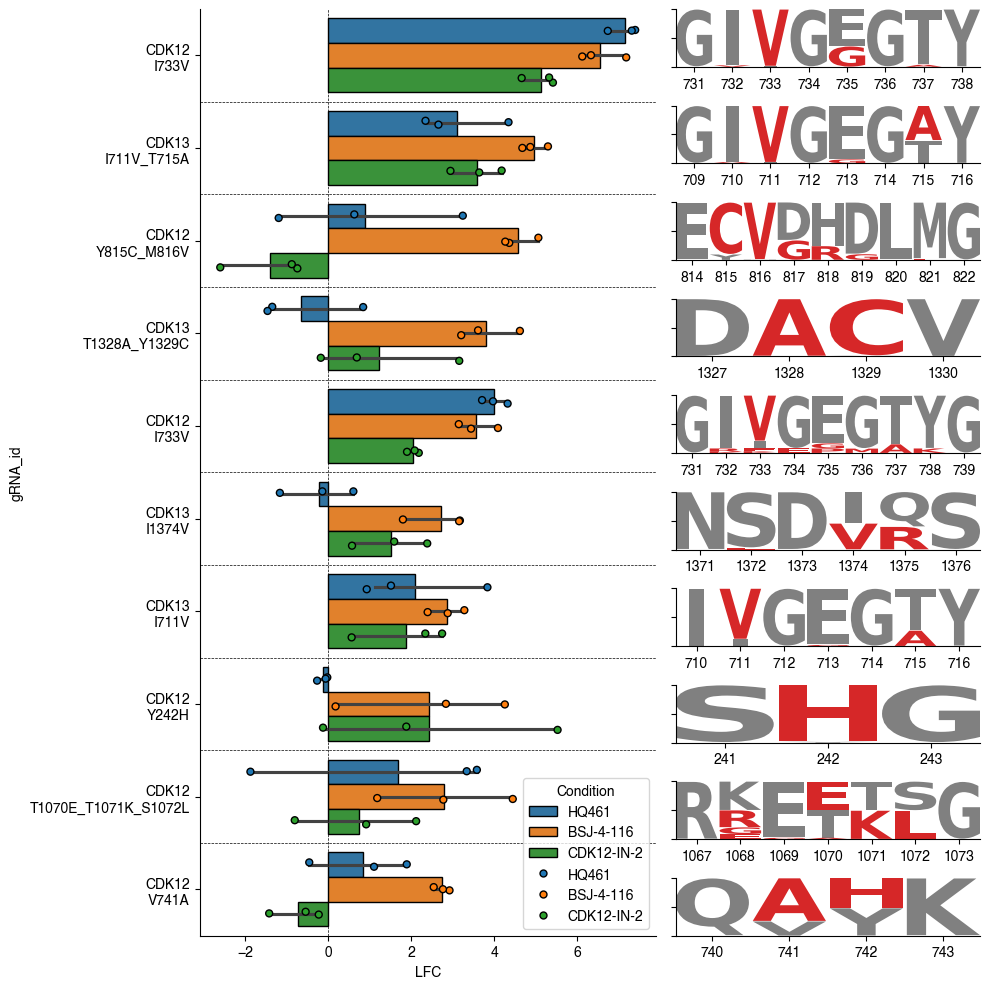

In [277]:
from matplotlib import gridspec


fig = plt.figure(figsize=(10, 10))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id'])


ax0 = plt.subplot(gs[:,0])

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, linewidth=1, edgecolor='black')
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black')


top_hg = []
for i, val in enumerate(guides):
    merge = SAV_ABE2
    gRNA_id = val
    context_size=1
    min_perc = 2

    logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

    ax1 = plt.subplot(gs[i,1])
    
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
    ss_logo.ax.set_yticks([0,50,100])
    ss_logo.ax.set_yticklabels([], fontsize=10);
    #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    #ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['right', 'top'], visible=False)

    subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
    

    g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
    hg = list(subset2['HGVSp'])[0]
    top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

# version with DNA? too much?

In [182]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(4, 2, width_ratios=[3, 1]) 
gs[0]

GridSpec(4, 2, width_ratios=[3, 1])[0:1, 0:1]

<Figure size 1200x600 with 0 Axes>